# Feature and Model Selection

The purpose of this notebook is to select features that will best indicate customer churn and select the best model based on these selected features.

# Import the Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc)

# Load the Dataset

In [6]:
df = pd.read_csv("dataset.csv")

df.head(6)

,Unnamed: 0,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,0,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,2,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,3,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,4,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
5,5,Female,0,0,0,8,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         7032 non-null   int64  
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   int64  
 4   dependents         7032 non-null   int64  
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   int64  
 7   multiple_lines     7032 non-null   object 
 8   internet_service   7032 non-null   object 
 9   online_security    7032 non-null   object 
 10  online_backup      7032 non-null   object 
 11  device_protection  7032 non-null   object 
 12  tech_support       7032 non-null   object 
 13  streaming_tv       7032 non-null   object 
 14  streaming_movies   7032 non-null   object 
 15  contract           7032 non-null   object 
 16  paperless_billing  7032 

# Separate Predictors and Target

In [8]:
X = df.drop(columns = ["churn"])
y = df["churn"]

# Convert Categorical Variables

In [9]:
X = pd.get_dummies(X, drop_first=True)

# Splitting the Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Scaling the Predictors

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature Selection

In [13]:
selector = SelectKBest(score_func=mutual_info_classif, k=10)

X_train_selected = selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]

print(selected_features)

Index(['tenure', 'monthly_charges', 'total_charges',
       'internet_service_Fiber optic', 'online_security_No internet service',
       'online_backup_No internet service', 'tech_support_No internet service',
       'streaming_movies_No internet service', 'contract_Two year',
       'payment_method_Electronic check'],
      dtype='object')


# Feature Selection Using Random Forest

In [14]:
rf = RandomForestClassifier(
    random_state = 42,
    n_estimators = 300
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by = "Importance",
    ascending = False
)

print(importance.head(15))

                            Feature  Importance
8                     total_charges    0.161296
4                            tenure    0.150294
7                   monthly_charges    0.134970
0                        Unnamed: 0    0.124488
12     internet_service_Fiber optic    0.038667
29  payment_method_Electronic check    0.035843
27                contract_Two year    0.033395
9                       gender_Male    0.023481
15              online_security_Yes    0.023218
26                contract_One year    0.022911
6                 paperless_billing    0.022148
21                 tech_support_Yes    0.021597
2                           partner    0.019901
17                online_backup_Yes    0.019817
11               multiple_lines_Yes    0.017982


It seems like the best variables are total_charges, tenure, and monthly_charges based on both the SelectKBest and Random Forest selections

In [15]:
top_features = ['total_charges','tenure','monthly_charges']

X_train_best = X_train[top_features]
X_test_best = X_test[top_features]

# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled[:, selector.get_support()], y_train)

LogisticRegression(max_iter=5000)

# Random Forest

In [17]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=300
)

rf_model.fit(X_train_best, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

# Gradient Boosting

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_best, y_train)

GradientBoostingClassifier(random_state=42)

# Support Vector Machine

In [19]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True
)

svm_model.fit(
    X_train_scaled[:, selector.get_support()],
    y_train
)

SVC(probability=True)

# Evaluate Every Model

In [24]:
pred = log_model.predict(
    X_test_scaled[:, selector.get_support()]
)

print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [34]:
rf_pred = rf_model.predict(X_test_best)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1033
           1       0.54      0.44      0.49       374

    accuracy                           0.75      1407
   macro avg       0.68      0.65      0.66      1407
weighted avg       0.74      0.75      0.74      1407



In [35]:
gb_pred = gb_model.predict(X_test_best)

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [32]:
pred =svm_model.predict(
    X_test_scaled[:, selector.get_support()]
)

print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



The model with the highest precision, f1-score, and overall recall scores is the logistic regression model. The gradient boosting and support vector machine models both have very similar numbers and the random forest model has the least amount of precision, recall, and f1-scores.

# Confusion Matrices

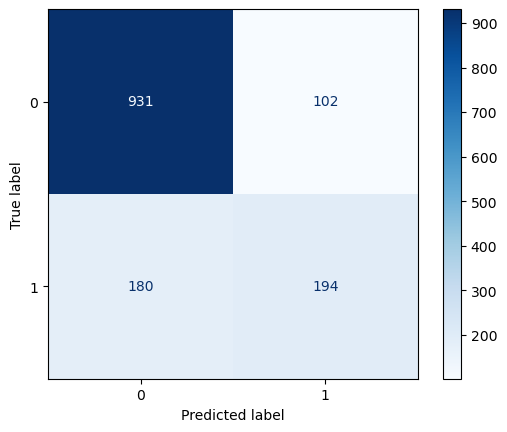

In [36]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled[:, selector.get_support()],
    y_test,
    cmap="Blues")
plt.show()

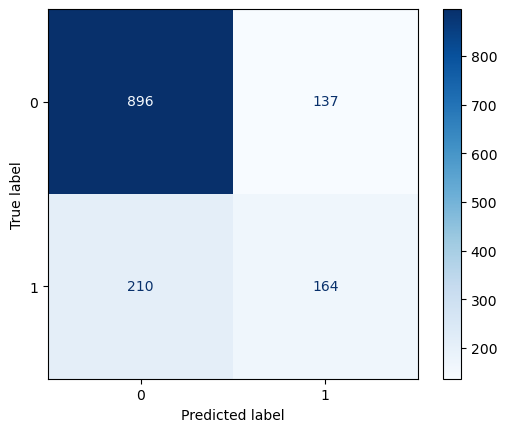

In [37]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_best,
    y_test,
    cmap="Blues")
plt.show()

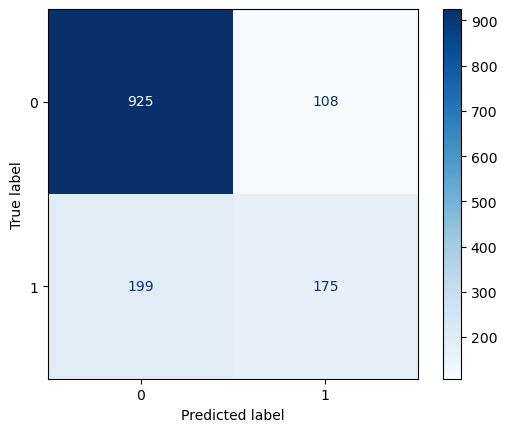

In [38]:
ConfusionMatrixDisplay.from_estimator(
    gb_model,
    X_test_best,
    y_test,
    cmap="Blues")
plt.show()

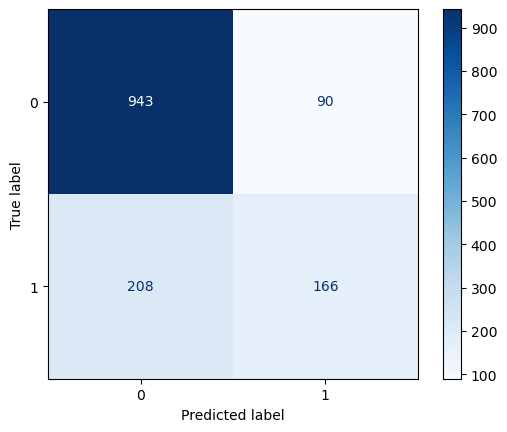

In [39]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_scaled[:, selector.get_support()],
    y_test,
    cmap="Blues")
plt.show()

The logistic regression model has the most correctly predicted values with 1,125 in total, the support vector machine model had 1,109, the gradient boosting model had 1,100, and the random forest model had 1,060.

# ROC Curves

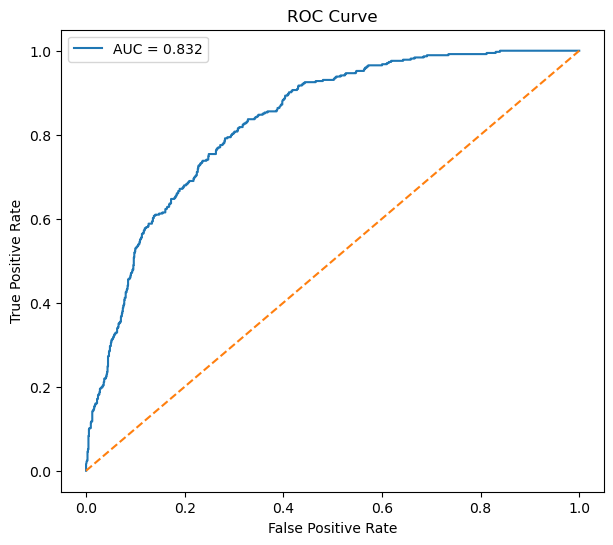

In [43]:
log_prob = log_model.predict_proba(
    X_test_scaled[:, selector.get_support()])[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    log_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

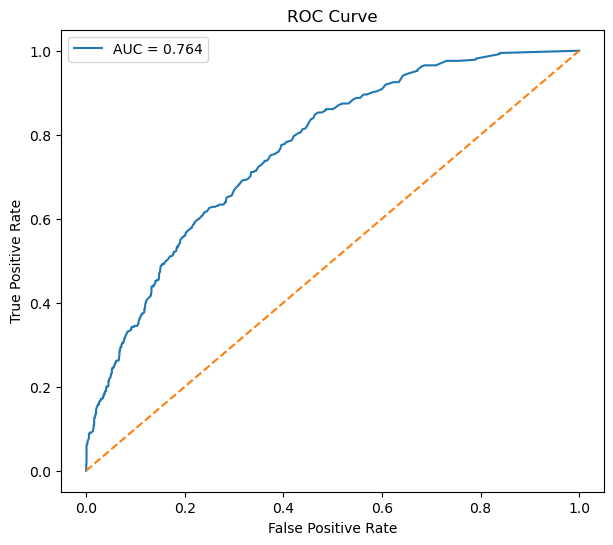

In [44]:
rf_prob = rf_model.predict_proba(
    X_test_best)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

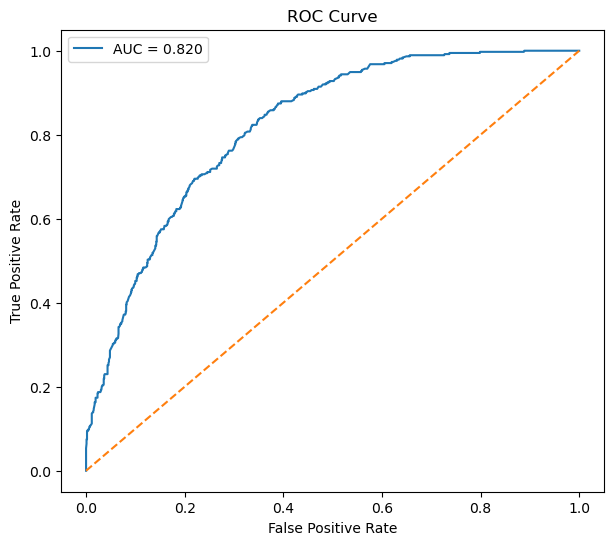

In [45]:
gb_prob = gb_model.predict_proba(
    X_test_best)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    gb_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

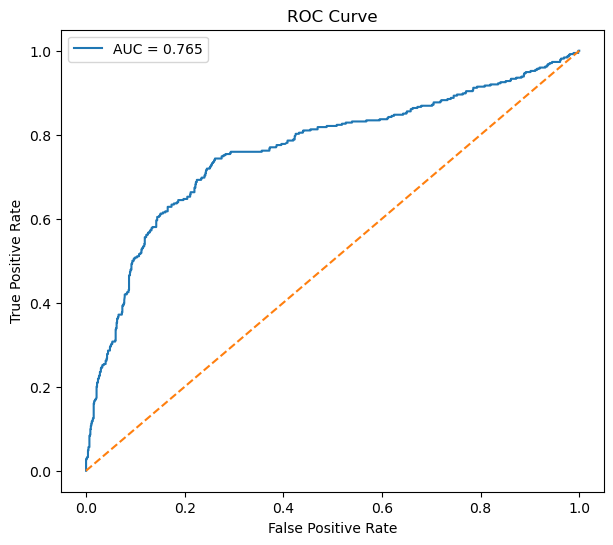

In [46]:
svm_prob = svm_model.predict_proba(
    X_test_scaled[:, selector.get_support()])[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    svm_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

AUC:
Logistic Regression: 0.832
Random Forest: 0.764
Gradient Boosting: 0.820
Support Vector Machine: 0.765

From these results, we can see that logistic regression has the most area under the curve followed closely by the gradient boosting model. They both have an AUC above 0.80, meaning they are useful models at predicting customer churn. The other models have a decent amount of AUC but do not perform as well.